
### Module 5: Semi-Supervised Learning &nbsp;|&nbsp; Module 6: Forecasting Models &nbsp;|&nbsp; Module 7: Deployment

we `pip install` it defensively just in case).

---
## Agenda

**Module 5 — Semi-Supervised Learning**
1. The problem: lots of unlabeled data, little labeled data
2. Self-Training
3. Label Propagation & Label Spreading (graph-based)

**Module 6 — Forecasting Models**
1. Time series basics: trend, seasonality, noise, stationarity
2. Naive & Moving Average baselines
3. Exponential Smoothing (Holt-Winters)
4. ARIMA / SARIMA
5. Forecast evaluation (RMSE, MAE, MAPE)

**Module 7 — Deployment of ML Models**
1. Serializing a trained model (pickle / joblib)
2. Building a reusable prediction function
3. Serving with Flask / FastAPI (code walkthrough)
4. A minimal Streamlit app (code walkthrough)
5. Monitoring & the deployment lifecycle (MLOps, conceptual)


## 🔧 Setup


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import joblib

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, mean_squared_error, mean_absolute_error
from sklearn.semi_supervised import SelfTrainingClassifier, LabelPropagation, LabelSpreading
from sklearn.svm import SVC

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 5)

print("✅ Libraries loaded. Ready to go!")


✅ Libraries loaded. Ready to go!


---
# Module 5: Semi-Supervised Learning

Labeling data is expensive (someone has to manually tag thousands of examples), but **unlabeled**
data is often cheap and abundant. Semi-supervised learning tries to get the best of both worlds:
train mostly on unlabeled data, using just a small labeled "seed" to guide it.

### Synthetic dataset: mostly unlabeled

We'll generate a classification dataset, then **hide the labels** for 95% of it — simulating a
real scenario where you only had time/budget to label a small fraction.


Total training points: 350
Labeled points: 17  |  Unlabeled points: 333


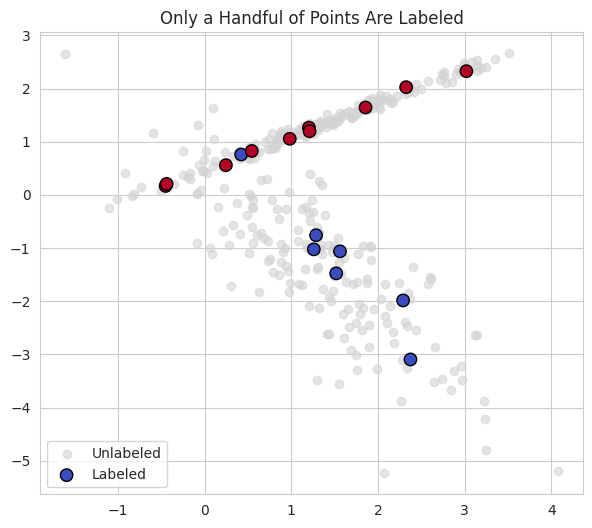

In [2]:
X, y_true = make_classification(
    n_samples=500, n_features=2, n_informative=2, n_redundant=0,
    n_clusters_per_class=1, class_sep=1.3, random_state=RANDOM_STATE
)

X_train, X_test, y_train_true, y_test = train_test_split(
    X, y_true, test_size=0.3, random_state=RANDOM_STATE, stratify=y_true
)

# Simulate scarce labels: keep only 5% of training labels, mask the rest as -1 (sklearn's "unlabeled" marker)
rng = np.random.RandomState(RANDOM_STATE)
n_labeled = int(0.05 * len(y_train_true))
labeled_idx = rng.choice(len(y_train_true), size=n_labeled, replace=False)

y_train_semi = np.full(len(y_train_true), -1)
y_train_semi[labeled_idx] = y_train_true[labeled_idx]

print(f"Total training points: {len(y_train_true)}")
print(f"Labeled points: {n_labeled}  |  Unlabeled points: {len(y_train_true) - n_labeled}")

plt.figure(figsize=(7, 6))
plt.scatter(X_train[y_train_semi == -1, 0], X_train[y_train_semi == -1, 1],
            c="lightgray", label="Unlabeled", alpha=0.6)
plt.scatter(X_train[y_train_semi != -1, 0], X_train[y_train_semi != -1, 1],
            c=y_train_semi[y_train_semi != -1], cmap="coolwarm", edgecolor="k", s=80, label="Labeled")
plt.legend()
plt.title("Only a Handful of Points Are Labeled")
plt.show()


### Baseline: train on labeled data only

If we throw away the unlabeled data and just train on the tiny labeled subset, how good is the model?


In [3]:
X_labeled_only = X_train[labeled_idx]
y_labeled_only = y_train_true[labeled_idx]

baseline_clf = LogisticRegression()
baseline_clf.fit(X_labeled_only, y_labeled_only)
baseline_acc = accuracy_score(y_test, baseline_clf.predict(X_test))
print(f"Baseline (labeled data only) test accuracy: {baseline_acc:.3f}")


Baseline (labeled data only) test accuracy: 0.920


### Self-Training

**Self-Training** wraps any classifier: it trains on the labeled data first, predicts labels for
the unlabeled points, keeps only the **most confident** predictions as new "pseudo-labels", adds
them to the training set, and repeats — gradually expanding the labeled set.


In [4]:
base_clf = SVC(probability=True, kernel="rbf", gamma="scale")
self_training = SelfTrainingClassifier(base_clf, threshold=0.8)
self_training.fit(X_train, y_train_semi)

self_train_acc = accuracy_score(y_test, self_training.predict(X_test))
print(f"Self-Training test accuracy: {self_train_acc:.3f}  (vs baseline {baseline_acc:.3f})")

n_pseudo_labeled = (self_training.transduction_ != -1).sum()
print(f"Points with a (pseudo-)label after training: {n_pseudo_labeled} / {len(y_train_semi)}")


Self-Training test accuracy: 0.927  (vs baseline 0.920)
Points with a (pseudo-)label after training: 341 / 350


### Label Propagation & Label Spreading

These are **graph-based** methods: imagine every point connected to its nearest neighbors by an
edge. Labels "flow" from labeled points to unlabeled ones along these edges — points closer to a
labeled point (in feature space) are more likely to inherit its label.

- **Label Propagation** clamps the original labeled points so they never change.
- **Label Spreading** allows a little "give" even on the original labels, making it more robust to noisy labels.


In [5]:
label_prop = LabelPropagation(kernel="knn", n_neighbors=7)
label_prop.fit(X_train, y_train_semi)
lp_acc = accuracy_score(y_test, label_prop.predict(X_test))

label_spread = LabelSpreading(kernel="knn", n_neighbors=7, alpha=0.2)
label_spread.fit(X_train, y_train_semi)
ls_acc = accuracy_score(y_test, label_spread.predict(X_test))

print(f"Label Propagation test accuracy: {lp_acc:.3f}")
print(f"Label Spreading test accuracy:   {ls_acc:.3f}")

comparison = pd.DataFrame({
    "Method": ["Labeled data only (baseline)", "Self-Training", "Label Propagation", "Label Spreading"],
    "Test Accuracy": [baseline_acc, self_train_acc, lp_acc, ls_acc]
}).sort_values("Test Accuracy", ascending=False)
comparison


Label Propagation test accuracy: 0.953
Label Spreading test accuracy:   0.893


,Method,Test Accuracy
2,Label Propagation,0.953333
1,Self-Training,0.926667
0,Labeled data only (baseline),0.920000
3,Label Spreading,0.893333


/tmp/ipykernel_987/1693786926.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison, x="Test Accuracy", y="Method", palette="viridis")


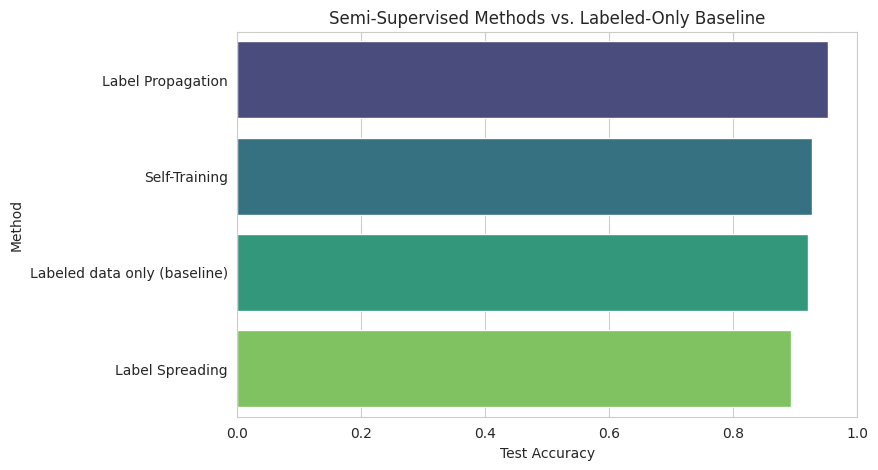

In [6]:
plt.figure(figsize=(8, 5))
sns.barplot(data=comparison, x="Test Accuracy", y="Method", palette="viridis")
plt.title("Semi-Supervised Methods vs. Labeled-Only Baseline")
plt.xlim(0, 1)
plt.show()


**🧪 Try it yourself:** drop `n_labeled` even further (e.g. 2% instead of 5%) and re-run — watch
the baseline collapse while the semi-supervised methods degrade far more gracefully, since they
still get to use the unlabeled data's structure.


---
# 📈 Module 6: Forecasting Models

Forecasting predicts **future values of a sequence over time** — revenue next quarter, tomorrow's
temperature, next week's website traffic. Unlike the earlier modules, order matters: you can't
shuffle a time series.


In [7]:
!pip install -q statsmodels


In [8]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


### Synthetic dataset: monthly sales with trend + seasonality + noise

We'll generate 5 years of monthly sales data with a clear upward trend and yearly seasonality
(e.g. a holiday-season spike), plus random noise.


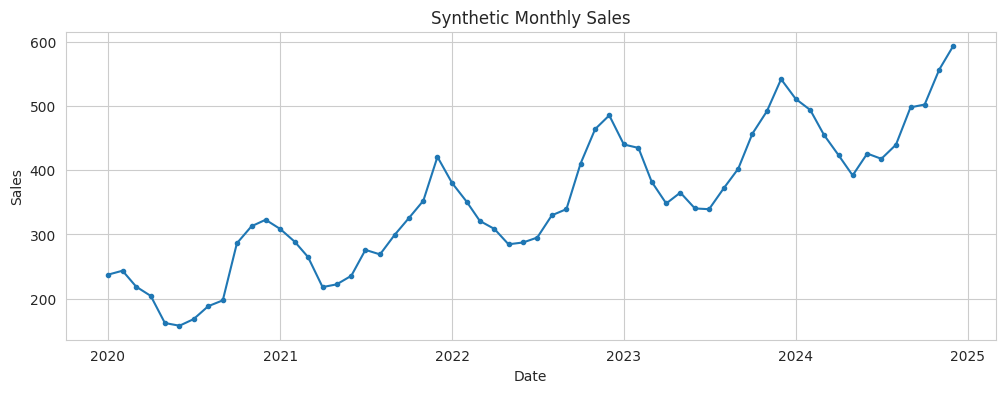

In [9]:
n_months = 60
dates = pd.date_range("2020-01-01", periods=n_months, freq="MS")

trend = np.linspace(200, 500, n_months)
seasonality = 60 * np.sin(2 * np.pi * (dates.month / 12) + 1.5) + 30 * (dates.month == 12)
noise = np.random.normal(0, 15, n_months)
sales = trend + seasonality + noise

ts = pd.Series(sales, index=dates, name="sales")

plt.figure(figsize=(12, 4))
plt.plot(ts, marker="o", markersize=3)
plt.title("Synthetic Monthly Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()


### Decomposition — separating trend, seasonality, and noise

Before modeling, it helps to visually confirm what components are present.


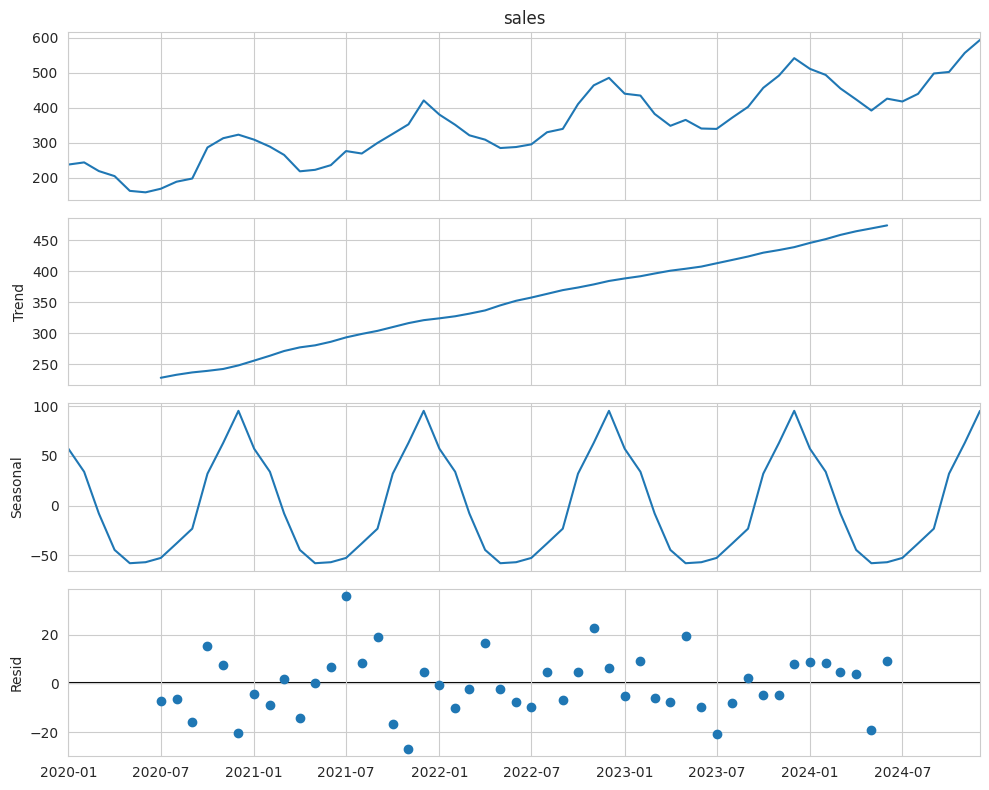

In [10]:
decomposition = seasonal_decompose(ts, model="additive", period=12)

fig = decomposition.plot()
fig.set_size_inches(10, 8)
plt.tight_layout()
plt.show()


### Train / Test Split (time-respecting)

Unlike earlier modules, we **never** shuffle before splitting — the test set must be the most
recent period, simulating "the future we haven't seen yet".


In [11]:
train_size = n_months - 12  # hold out the last 12 months to test forecasts
train, test = ts.iloc[:train_size], ts.iloc[train_size:]

print(f"Train: {train.index.min().date()} to {train.index.max().date()} ({len(train)} months)")
print(f"Test:  {test.index.min().date()} to {test.index.max().date()} ({len(test)} months)")


Train: 2020-01-01 to 2023-12-01 (48 months)
Test:  2024-01-01 to 2024-12-01 (12 months)


### Baselines: Naive Forecast & Moving Average

Always start forecasting projects with a dumb baseline — if a fancy model can't beat it, it's not
worth the complexity.
- **Naive forecast**: tomorrow = today (or, for seasonal data, this month = same month last year)
- **Moving average**: average of the last N periods


In [12]:
# Seasonal naive: repeat the value from 12 months ago
naive_forecast = train.iloc[-12:].values
naive_forecast = pd.Series(naive_forecast, index=test.index)

# Simple moving average of the last 6 months of training data, held flat
ma_forecast = pd.Series([train.iloc[-6:].mean()] * len(test), index=test.index)

def evaluate(actual, predicted, name):
    rmse = mean_squared_error(actual, predicted) ** 0.5
    mae = mean_absolute_error(actual, predicted)
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    print(f"{name:25s} RMSE={rmse:7.2f}  MAE={mae:7.2f}  MAPE={mape:5.2f}%")
    return {"Model": name, "RMSE": rmse, "MAE": mae, "MAPE": mape}

results = []
results.append(evaluate(test, naive_forecast, "Seasonal Naive"))
results.append(evaluate(test, ma_forecast, "Moving Average"))


Seasonal Naive            RMSE=  68.66  MAE=  66.32  MAPE=14.13%
Moving Average            RMSE=  71.73  MAE=  54.69  MAPE=10.63%


### Exponential Smoothing (Holt-Winters)

Holt-Winters extends a simple moving average with three smoothing components: **level**, **trend**,
and **seasonality** — a great default for data with both trend and seasonal patterns, like ours.


In [13]:
hw_model = ExponentialSmoothing(
    train, trend="add", seasonal="add", seasonal_periods=12
).fit()

hw_forecast = hw_model.forecast(len(test))
results.append(evaluate(test, hw_forecast, "Holt-Winters"))


Holt-Winters              RMSE=  15.13  MAE=  11.68  MAPE= 2.50%


### ARIMA & SARIMA

- **ARIMA(p, d, q)** models a series using its own past values (**A**uto**R**egressive), differencing
  to remove trend (**I**ntegrated), and past forecast errors (**M**oving **A**verage).
- **SARIMA** adds a seasonal version of the same three components on top — necessary here since our
  data has a clear yearly cycle that plain ARIMA can't capture well.

ACF/PACF plots help choose `p` and `q`, but for the workshop we'll pick reasonable values directly
and focus on the forecasting workflow.


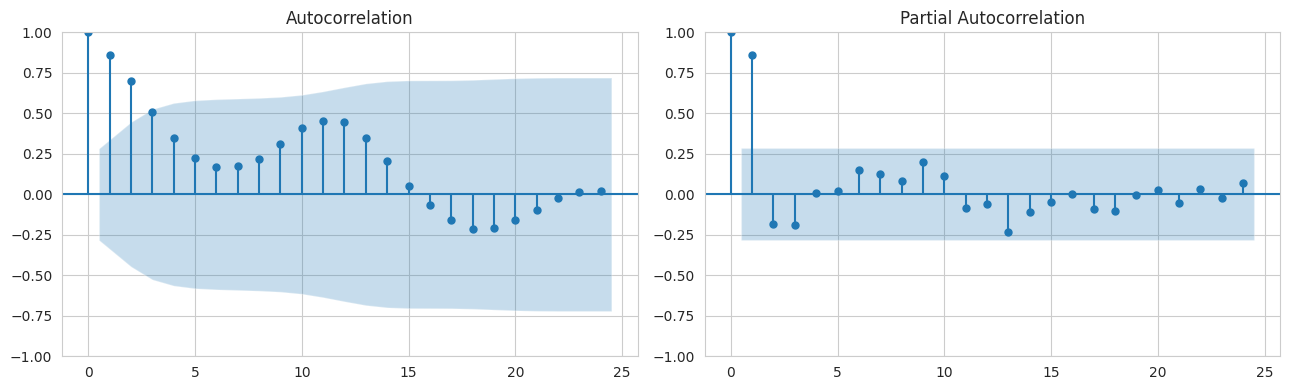

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_acf(train, ax=axes[0], lags=24)
plot_pacf(train, ax=axes[1], lags=24)
plt.tight_layout()
plt.show()


In [15]:
arima_model = ARIMA(train, order=(2, 1, 2)).fit()
arima_forecast = arima_model.forecast(steps=len(test))
results.append(evaluate(test, arima_forecast, "ARIMA(2,1,2)"))

sarima_model = SARIMAX(
    train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12)
).fit(disp=False)
sarima_forecast = sarima_model.forecast(steps=len(test))
results.append(evaluate(test, sarima_forecast, "SARIMA(1,1,1)(1,1,1,12)"))


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


ARIMA(2,1,2)              RMSE=  25.98  MAE=  21.90  MAPE= 4.51%
SARIMA(1,1,1)(1,1,1,12)   RMSE=  15.31  MAE=  13.23  MAPE= 2.80%


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


### Comparing all forecasts


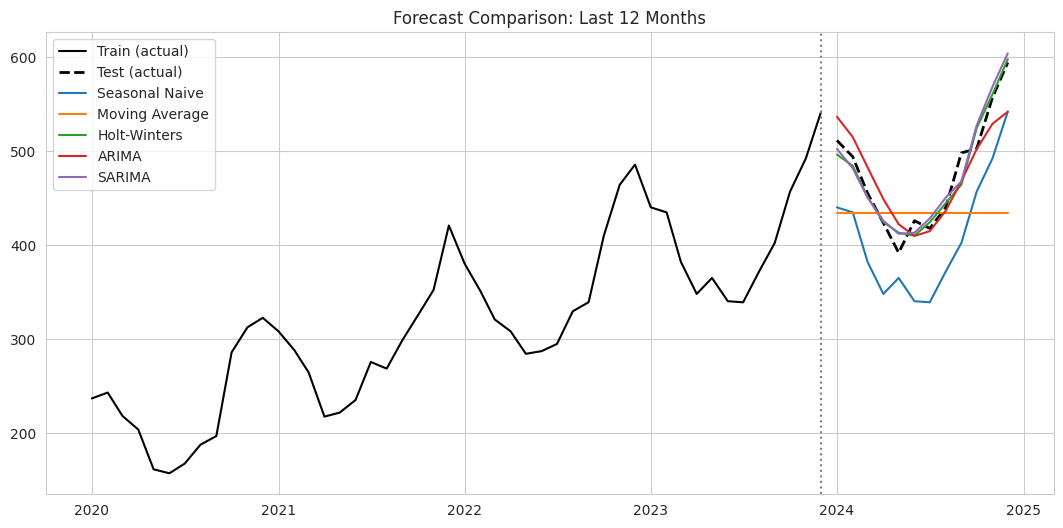

,Model,RMSE,MAE,MAPE
2,Holt-Winters,15.132207,11.680801,2.502447
4,"SARIMA(1,1,1)(1,1,1,12)",15.310182,13.227786,2.801774
3,"ARIMA(2,1,2)",25.975237,21.897400,4.514208
0,Seasonal Naive,68.660703,66.323041,14.130730
1,Moving Average,71.731402,54.688564,10.634307


In [16]:
plt.figure(figsize=(13, 6))
plt.plot(train.index, train, label="Train (actual)", color="black")
plt.plot(test.index, test, label="Test (actual)", color="black", linestyle="--", linewidth=2)
plt.plot(test.index, naive_forecast, label="Seasonal Naive")
plt.plot(test.index, ma_forecast, label="Moving Average")
plt.plot(test.index, hw_forecast, label="Holt-Winters")
plt.plot(test.index, arima_forecast, label="ARIMA")
plt.plot(test.index, sarima_forecast, label="SARIMA")
plt.axvline(train.index[-1], color="gray", linestyle=":")
plt.legend()
plt.title("Forecast Comparison: Last 12 Months")
plt.show()

results_df = pd.DataFrame(results).sort_values("RMSE")
results_df


**🧪 Try it yourself:** change `seasonal_order=(1, 1, 1, 12)` to `(0, 1, 1, 12)` in SARIMA and
compare RMSE — small changes to these orders can meaningfully shift forecast quality.


---
#  Module 7: Deployment of ML Models

A model sitting in a notebook delivers zero business value — it has to be **deployed** somewhere
that other software (or people) can call it. This module covers the standard path from
"trained model" to "running service", using our Module 1 churn-style problem as the example model.


## 7.1 Train a model to deploy

We'll quickly train a Random Forest on a synthetic churn-like dataset, matching the structure from
Module 1 (Pipeline) — this is the model we'll "deploy" through the rest of this section.


In [17]:
X_dep, y_dep = make_classification(
    n_samples=800, n_features=6, n_informative=4, n_redundant=1,
    weights=[0.75, 0.25], random_state=RANDOM_STATE
)
feature_names = ["tenure_months", "monthly_charges", "total_charges",
                  "support_calls", "contract_month_to_month", "avg_monthly_spend"]
X_dep_df = pd.DataFrame(X_dep, columns=feature_names)

X_train_dep, X_test_dep, y_train_dep, y_test_dep = train_test_split(
    X_dep_df, y_dep, test_size=0.2, random_state=RANDOM_STATE, stratify=y_dep
)

deploy_model = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=RANDOM_STATE)
deploy_model.fit(X_train_dep, y_train_dep)

print(f"Test accuracy: {accuracy_score(y_test_dep, deploy_model.predict(X_test_dep)):.3f}")


Test accuracy: 0.863


## 7.2 Serializing the model (pickle / joblib)

Before deployment, the trained model object needs to be saved to disk so a separate application
(a web server, an API, a scheduled job) can load it **without retraining**.

`joblib` is generally preferred over raw `pickle` for scikit-learn models — it's more efficient for
objects containing large NumPy arrays (like tree ensembles).


In [18]:
import os
os.makedirs("model_artifacts", exist_ok=True)

# joblib (recommended for sklearn models)
joblib.dump(deploy_model, "model_artifacts/churn_model.joblib")

# pickle (more general-purpose, works for almost any Python object)
with open("model_artifacts/churn_model.pkl", "wb") as f:
    pickle.dump(deploy_model, f)

print("Saved model files:", os.listdir("model_artifacts"))


Saved model files: ['churn_model.joblib', 'churn_model.pkl']


### Loading it back and confirming it still works

This simulates what happens in production: a *different* process loads the file and uses it —
no access to the original training code or data.


In [19]:
loaded_model = joblib.load("model_artifacts/churn_model.joblib")

sample_customer = X_test_dep.iloc[[0]]
prediction = loaded_model.predict(sample_customer)[0]
probability = loaded_model.predict_proba(sample_customer)[0, 1]

print(f"Sample input:\n{sample_customer}")
print(f"\nPredicted churn: {bool(prediction)}  (probability: {probability:.2%})")


Sample input:
     tenure_months  monthly_charges  total_charges  support_calls  \
440      -2.911548         3.731036       3.658798       2.318549   

     contract_month_to_month  avg_monthly_spend  
440                -4.251028          -2.580372  

Predicted churn: True  (probability: 52.41%)


## 7.3 A reusable prediction function

Wrapping inference in a clean function is the piece every deployment option below (Flask, FastAPI,
Streamlit) will call directly.


In [20]:
def predict_churn(input_dict, model=loaded_model, feature_order=feature_names):
    """
    input_dict: dict like {"tenure_months": 12, "monthly_charges": 70.5, ...}
    Returns: dict with prediction and probability
    """
    row = pd.DataFrame([[input_dict[f] for f in feature_order]], columns=feature_order)
    pred = model.predict(row)[0]
    proba = model.predict_proba(row)[0, 1]
    return {"churn_prediction": bool(pred), "churn_probability": round(float(proba), 4)}

example_input = dict(zip(feature_names, X_test_dep.iloc[2].values))
predict_churn(example_input)


{'churn_prediction': False, 'churn_probability': 0.1079}

## 7.4 Serving with Flask

Flask is the most common lightweight way to expose a model as a **REST API** — other applications
send an HTTP request with input data and get a JSON prediction back.

> This code won't run inside a notebook cell (it needs to run as a standalone script and stay
> listening for requests), so it's shown here for you to copy into a `app.py` file and run with
> `python app.py`.


In [21]:
flask_app_code = '''
# app.py
from flask import Flask, request, jsonify
import joblib
import pandas as pd

app = Flask(__name__)
model = joblib.load("model_artifacts/churn_model.joblib")
feature_names = ["tenure_months", "monthly_charges", "total_charges",
                  "support_calls", "contract_month_to_month", "avg_monthly_spend"]

@app.route("/predict", methods=["POST"])
def predict():
    data = request.get_json()
    row = pd.DataFrame([[data[f] for f in feature_names]], columns=feature_names)
    prediction = model.predict(row)[0]
    probability = model.predict_proba(row)[0, 1]
    return jsonify({
        "churn_prediction": bool(prediction),
        "churn_probability": round(float(probability), 4)
    })

if __name__ == "__main__":
    app.run(debug=True, port=5000)
'''
print(flask_app_code)



# app.py
from flask import Flask, request, jsonify
import joblib
import pandas as pd

app = Flask(__name__)
model = joblib.load("model_artifacts/churn_model.joblib")
feature_names = ["tenure_months", "monthly_charges", "total_charges",
                  "support_calls", "contract_month_to_month", "avg_monthly_spend"]

@app.route("/predict", methods=["POST"])
def predict():
    data = request.get_json()
    row = pd.DataFrame([[data[f] for f in feature_names]], columns=feature_names)
    prediction = model.predict(row)[0]
    probability = model.predict_proba(row)[0, 1]
    return jsonify({
        "churn_prediction": bool(prediction),
        "churn_probability": round(float(probability), 4)
    })

if __name__ == "__main__":
    app.run(debug=True, port=5000)



Once running, you'd call it like:

```bash
curl -X POST http://localhost:5000/predict \
     -H "Content-Type: application/json" \
     -d '{"tenure_months": 5, "monthly_charges": 90, "total_charges": 450, "support_calls": 4, "contract_month_to_month": 1, "avg_monthly_spend": 90}'
```


## 7.5 Serving with FastAPI

FastAPI is a modern alternative to Flask with automatic input validation and interactive docs
(`/docs`) generated for free — increasingly the default choice for new ML APIs.


In [22]:
fastapi_app_code = '''
# main.py
from fastapi import FastAPI
from pydantic import BaseModel
import joblib
import pandas as pd

app = FastAPI()
model = joblib.load("model_artifacts/churn_model.joblib")

class CustomerFeatures(BaseModel):
    tenure_months: float
    monthly_charges: float
    total_charges: float
    support_calls: float
    contract_month_to_month: float
    avg_monthly_spend: float

@app.post("/predict")
def predict(features: CustomerFeatures):
    row = pd.DataFrame([features.dict()])
    prediction = model.predict(row)[0]
    probability = model.predict_proba(row)[0, 1]
    return {
        "churn_prediction": bool(prediction),
        "churn_probability": round(float(probability), 4)
    }

# Run with: uvicorn main:app --reload
'''
print(fastapi_app_code)



# main.py
from fastapi import FastAPI
from pydantic import BaseModel
import joblib
import pandas as pd

app = FastAPI()
model = joblib.load("model_artifacts/churn_model.joblib")

class CustomerFeatures(BaseModel):
    tenure_months: float
    monthly_charges: float
    total_charges: float
    support_calls: float
    contract_month_to_month: float
    avg_monthly_spend: float

@app.post("/predict")
def predict(features: CustomerFeatures):
    row = pd.DataFrame([features.dict()])
    prediction = model.predict(row)[0]
    probability = model.predict_proba(row)[0, 1]
    return {
        "churn_prediction": bool(prediction),
        "churn_probability": round(float(probability), 4)
    }

# Run with: uvicorn main:app --reload



## 7.6 A minimal Streamlit app (interactive UI, no API needed)

Streamlit is the fastest way to give non-technical stakeholders a **clickable interface** for a
model — sliders and buttons instead of a REST API and curl commands.


In [23]:
streamlit_app_code = '''
# streamlit_app.py
import streamlit as st
import joblib
import pandas as pd

model = joblib.load("model_artifacts/churn_model.joblib")

st.title("Customer Churn Predictor")

tenure = st.slider("Tenure (months)", 0, 72, 12)
monthly_charges = st.slider("Monthly Charges ($)", 0, 200, 70)
total_charges = st.number_input("Total Charges ($)", value=800.0)
support_calls = st.slider("Support Calls", 0, 10, 2)
month_to_month = st.checkbox("Month-to-month contract?")
avg_spend = st.number_input("Avg Monthly Spend ($)", value=70.0)

if st.button("Predict"):
    row = pd.DataFrame([[tenure, monthly_charges, total_charges,
                          support_calls, int(month_to_month), avg_spend]],
                        columns=["tenure_months", "monthly_charges", "total_charges",
                                 "support_calls", "contract_month_to_month", "avg_monthly_spend"])
    proba = model.predict_proba(row)[0, 1]
    st.metric("Churn Probability", f"{proba:.1%}")

# Run with: streamlit run streamlit_app.py
'''
print(streamlit_app_code)



# streamlit_app.py
import streamlit as st
import joblib
import pandas as pd

model = joblib.load("model_artifacts/churn_model.joblib")

st.title("Customer Churn Predictor")

tenure = st.slider("Tenure (months)", 0, 72, 12)
monthly_charges = st.slider("Monthly Charges ($)", 0, 200, 70)
total_charges = st.number_input("Total Charges ($)", value=800.0)
support_calls = st.slider("Support Calls", 0, 10, 2)
month_to_month = st.checkbox("Month-to-month contract?")
avg_spend = st.number_input("Avg Monthly Spend ($)", value=70.0)

if st.button("Predict"):
    row = pd.DataFrame([[tenure, monthly_charges, total_charges,
                          support_calls, int(month_to_month), avg_spend]],
                        columns=["tenure_months", "monthly_charges", "total_charges",
                                 "support_calls", "contract_month_to_month", "avg_monthly_spend"])
    proba = model.predict_proba(row)[0, 1]
    st.metric("Churn Probability", f"{proba:.1%}")

# Run with: streamlit run 

## 7.7 Beyond the first deploy: monitoring & the ML lifecycle

Shipping the model isn't the finish line. A few things teams set up in production:

- **Containerization (Docker)**: package the model + code + dependencies into one portable image so
  it runs identically on any machine or cloud provider.
- **Monitoring**: track prediction latency, error rates, and — critically — **model/data drift**
  (are incoming customers starting to look different from training data? Is accuracy silently
  degrading?).
- **Retraining pipelines**: schedule periodic retraining on fresh data, with automated evaluation
  gates before a new model version replaces the old one.
- **Versioning**: keep track of which model + which data + which code produced any given prediction,
  so issues can be traced and rolled back.

This overall discipline — treating ML models like production software with CI/CD, monitoring, and
rollback plans — is generally called **MLOps**.


---
## ✅ Recap — and the full workshop, end to end

**Module 5 — Semi-Supervised Learning:** with only 5% of labels available, Self-Training,
Label Propagation, and Label Spreading all beat a labeled-only baseline by also learning from the
unlabeled majority of the data.

**Module 6 — Forecasting:** we decomposed a synthetic sales series into trend/seasonality/noise,
built naive and moving-average baselines, then compared Holt-Winters, ARIMA, and SARIMA using
RMSE/MAE/MAPE on a held-out final year.

**Module 7 — Deployment:** we serialized a trained model with joblib, wrapped it in a clean
prediction function, and walked through Flask, FastAPI, and Streamlit code for serving it — plus
what comes after deployment (monitoring, retraining, MLOps).

### 🎓 Full Workshop Series
1. Machine Learning Pipeline
2. Supervised Learning
3. Unsupervised Learning
4. Reinforcement Learning
5. Semi-Supervised Learning
6. Forecasting Models
7. Deployment of ML Models
